# Parcial 1 — Parte 1 — Minería de Datos
**Profesor:** Pierre Rosado — Universidad del Norte
**Dataset:** Online Retail II (UCI ML Repository)

Este notebook desarrolla la carga, el EDA, la limpieza de datos y la construcción de las canastas (baskets) para el dataset *Online Retail II*.


## 0. Preparación del entorno

Subir el archivo `online_retail_II.xlsx` (descargado y descomprimido desde https://archive.ics.uci.edu/dataset/502/online+retail+ii) al entorno de Colab, por ejemplo con `files.upload()` o montando Google Drive.


In [1]:
# Si estás en Google Colab, descomenta para subir el archivo:
# from google.colab import files
# uploaded = files.upload()

import re
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "online_retail_II.xlsx"


## 2. Cargar los datos y EDA (Exploratory Data Analysis)

In [2]:
xls = pd.ExcelFile(DATA_PATH)
print("Hojas del archivo Excel:", xls.sheet_names)

df = pd.concat(
    [pd.read_excel(xls, sheet_name=s) for s in xls.sheet_names],
    ignore_index=True
)
df.head()


Hojas del archivo Excel: ['Year 2009-2010', 'Year 2010-2011']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Pregunta 2.1
a) ¿Cuál es la columna que identifica a las canastas?
b) ¿Cuál es la columna que identifica a los ítems?


In [3]:
print("a) Columna que identifica las canastas: 'Invoice'")
print("b) Columna que identifica los ítems: 'StockCode'")


a) Columna que identifica las canastas: 'Invoice'
b) Columna que identifica los ítems: 'StockCode'


**Respuesta 2.1:**
- a) `Invoice` identifica la canasta (cada factura/transacción agrupa los ítems comprados juntos).
- b) `StockCode` identifica el ítem (código único de producto).


### Pregunta 2.2 — ¿Cuántas filas tiene el dataset originalmente?

In [4]:
n_filas_originales = len(df)
print("Filas originales:", n_filas_originales)


Filas originales: 1067371


**Respuesta 2.2:** El dataset original tiene **1,067,371** filas (unión de las dos hojas 2009-2010 y 2010-2011).

### Pregunta 2.3 — EDA
a) ¿Cuántas filas tienen valores nulos en `Invoice` o `StockCode`?
b) ¿Cuántas filas tienen un `Invoice` que empieza con "C"?
c) Identificar los `StockCode` que no siguen el patrón de 5 dígitos con sufijo de letra opcional (68 valores únicos esperados).


In [5]:
# a) Nulos en Invoice o StockCode
nulos_invoice_o_stock = df["Invoice"].isna() | df["StockCode"].isna()
print("a) Filas con nulos en Invoice o StockCode:", nulos_invoice_o_stock.sum())


a) Filas con nulos en Invoice o StockCode: 0


In [6]:
# b) Invoices que empiezan con 'C' (cancelaciones)
invoice_str = df["Invoice"].astype(str)
cancelaciones = invoice_str.str.startswith("C")
print("b) Filas con Invoice que empieza con 'C':", cancelaciones.sum())


b) Filas con Invoice que empieza con 'C': 19494


In [7]:
# c) StockCodes que no siguen el patrón 5 dígitos + sufijo de letra opcional
patron = re.compile(r"^\d{5}[A-Za-z]?$")
stockcode_str = df["StockCode"].astype(str)
no_cumple_patron = ~stockcode_str.str.match(patron)

stockcodes_atipicos = sorted(stockcode_str[no_cumple_patron].unique().tolist())
print("c) Cantidad de StockCodes que no siguen el patrón:", len(stockcodes_atipicos))
stockcodes_atipicos


c) Cantidad de StockCodes que no siguen el patrón: 68


['15056BL',
 '15056bl',
 '47503J ',
 '72024HC',
 '79323GR',
 '79323LP',
 'ADJUST',
 'ADJUST2',
 'AMAZONFEE',
 'B',
 'BANK CHARGES',
 'C2',
 'C3',
 'CRUK',
 'D',
 'DCGS0003',
 'DCGS0004',
 'DCGS0006',
 'DCGS0016',
 'DCGS0027',
 'DCGS0036',
 'DCGS0037',
 'DCGS0039',
 'DCGS0041',
 'DCGS0044',
 'DCGS0053',
 'DCGS0055',
 'DCGS0056',
 'DCGS0057',
 'DCGS0058',
 'DCGS0059',
 'DCGS0060',
 'DCGS0062',
 'DCGS0066N',
 'DCGS0066P',
 'DCGS0067',
 'DCGS0068',
 'DCGS0069',
 'DCGS0070',
 'DCGS0071',
 'DCGS0072',
 'DCGS0073',
 'DCGS0074',
 'DCGS0075',
 'DCGS0076',
 'DCGSLBOY',
 'DCGSLGIRL',
 'DCGSSBOY',
 'DCGSSGIRL',
 'DOT',
 'GIFT',
 'M',
 'PADS',
 'POST',
 'S',
 'SP1002',
 'TEST001',
 'TEST002',
 'gift_0001_10',
 'gift_0001_20',
 'gift_0001_30',
 'gift_0001_40',
 'gift_0001_50',
 'gift_0001_60',
 'gift_0001_70',
 'gift_0001_80',
 'gift_0001_90',
 'm']

**Respuesta 2.3:**
- a) **0** filas tienen nulos en `Invoice` o `StockCode`.
- b) **19,494** filas tienen `Invoice` que empieza con "C" (cancelaciones).
- c) Se encuentran **68** valores únicos de `StockCode` que no siguen el patrón de 5 dígitos + sufijo de letra opcional (códigos administrativos como `POST`, `D`, `DOT`, `M`, `BANK CHARGES`, `ADJUST`, códigos `DCGS...`, `gift_...`, `TEST00x`, etc.).


## 3. Limpieza de datos

In [8]:
df_clean = df.copy()
df_clean["Invoice"] = df_clean["Invoice"].astype(str)
df_clean["StockCode"] = df_clean["StockCode"].astype(str)

# Eliminar cancelaciones (Invoice empieza con 'C')
df_clean = df_clean[~df_clean["Invoice"].str.startswith("C")]

# Conservar solo Quantity > 0
df_clean = df_clean[df_clean["Quantity"] > 0]

# Eliminar stock codes no-producto
non_product_codes = {
    "POST", "D", "DOT", "M", "S", "AMAZONFEE",
    "BANK CHARGES", "PADS", "CRUK", "C2", "m"
}
df_clean = df_clean[~df_clean["StockCode"].isin(non_product_codes)]

# Eliminar stock codes de longitud 1
df_clean = df_clean[df_clean["StockCode"].str.len() != 1]

# Eliminar filas con Customer ID nulo
df_clean = df_clean[df_clean["Customer ID"].notna()]

print("Filas tras limpieza:      ", len(df_clean))
print("StockCodes únicos:        ", df_clean["StockCode"].nunique())
print("Invoices únicos:          ", df_clean["Invoice"].nunique())


Filas tras limpieza:       802742
StockCodes únicos:         4624
Invoices únicos:           36644


In [9]:
# Verificación contra los valores esperados por el enunciado
assert len(df_clean) == 802_742
assert df_clean["StockCode"].nunique() == 4_624
assert df_clean["Invoice"].nunique() == 36_644
print("Verificación OK: 802,742 filas | 4,624 StockCodes únicos | 36,644 Invoices únicos")


Verificación OK: 802,742 filas | 4,624 StockCodes únicos | 36,644 Invoices únicos


**Resultado de la limpieza:** 802,742 filas, 4,624 StockCodes únicos y 36,644 Invoices únicos, coincidiendo exactamente con la verificación pedida en el enunciado.

## 4. Construir los baskets

### 4.1 ¿Por qué usar `frozenset`?

`frozenset` es la versión **inmutable** del tipo `set` en Python. Es importante para representar los ítems de una canasta porque:

- **Inmutabilidad / hashabilidad:** un `frozenset` no puede modificarse después de creado, por lo que puede usarse como clave de diccionario o como elemento dentro de otro `set`, cosa que un `set` normal no permite (no es *hashable*). Esto es clave para algoritmos de reglas de asociación (p. ej. Apriori) donde los itemsets se usan como claves de conteo.
- **Sin duplicados ni orden:** al igual que `set`, elimina duplicados y no importa el orden de los ítems — dos canastas con los mismos ítems en distinto orden se consideran el mismo itemset, lo cual es la semántica correcta para "canasta de compra".
- **Comparación de subconjuntos eficiente:** permite operaciones de conjuntos (unión, intersección, subconjunto) muy usadas al generar y contar itemsets candidatos.
- **Seguridad:** evita que una canasta se modifique accidentalmente durante el procesamiento, garantizando resultados reproducibles.


In [10]:
baskets_series = df_clean.groupby("Invoice")["StockCode"].apply(lambda s: frozenset(s))

n_canastas = len(baskets_series)
print("Total de canastas:", n_canastas)
assert n_canastas == 36_644


Total de canastas: 36644


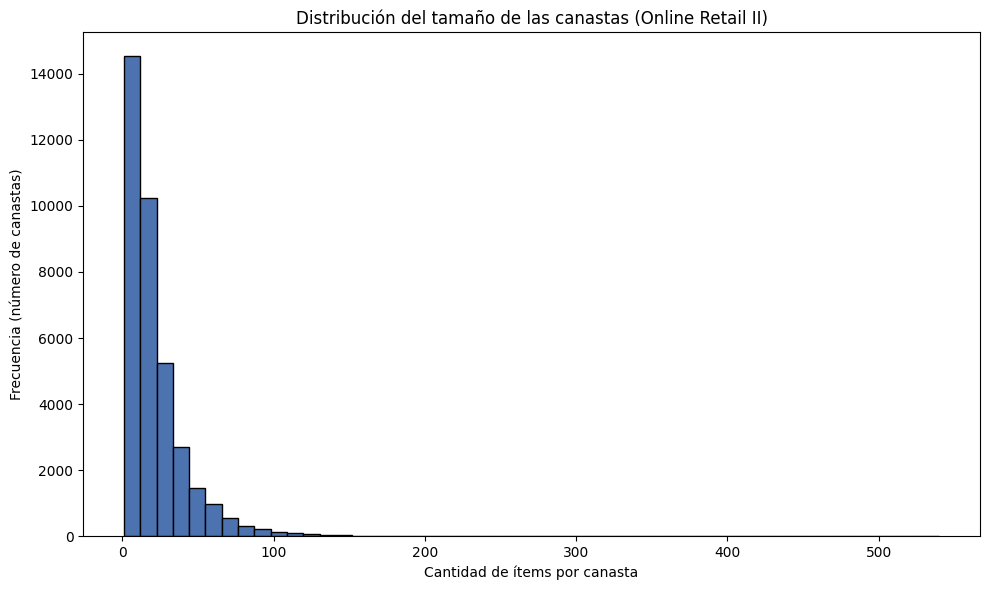

Tamaño mínimo:   1
Tamaño máximo:   540
Tamaño promedio: 20.91
Tamaño mediana:  15.0


In [11]:
basket_sizes = baskets_series.apply(len)

plt.figure(figsize=(10, 6))
plt.hist(basket_sizes, bins=50, color="#4C72B0", edgecolor="black")
plt.title("Distribución del tamaño de las canastas (Online Retail II)")
plt.xlabel("Cantidad de ítems por canasta")
plt.ylabel("Frecuencia (número de canastas)")
plt.tight_layout()
plt.savefig("basket_size_histogram.png", dpi=150)
plt.show()

print("Tamaño mínimo:  ", basket_sizes.min())
print("Tamaño máximo:  ", basket_sizes.max())
print("Tamaño promedio:", round(basket_sizes.mean(), 2))
print("Tamaño mediana: ", basket_sizes.median())


In [12]:
# Guardar las canastas en un archivo CSV
baskets_df = pd.DataFrame({
    "Invoice": baskets_series.index,
    "Items": baskets_series.apply(lambda fs: ",".join(sorted(fs)))
})
baskets_df.to_csv("baskets.csv", index=False)
baskets_df.head()


,Invoice,Items
Invoice,,
489434,489434,"21232,21523,21871,22041,22064,79323P,79323W,85048"
489435,489435,"22195,22349,22350,22353"
489436,489436,"21181,21333,21754,21755,21756,22107,22109,2211..."
489437,489437,"10002,20695,20703,20971,21351,21352,21360,2136..."
489438,489438,"20711,21033,21100,21252,21329,21410,21411,8403..."


**Resumen final:** se construyeron **36,644** canastas, cada una representada en tiempo de ejecución como un `frozenset` de `StockCode`, y se exportaron a `baskets.csv` (una fila por `Invoice`, con sus ítems separados por coma) para su uso posterior en algoritmos de reglas de asociación (p. ej. Apriori / FP-Growth).

# Parcial 1 — Parte 2

Continuando con las canastas construidas en la Parte 1, se implementa el algoritmo **A-Priori** y la **generación de reglas de asociación**.


## 1. Algoritmo A-Priori

### Implementación

In [13]:
import math
from collections import defaultdict
from itertools import combinations


def generate_candidates(prev_itemsets, k):
    """Genera candidatos Ck a partir de Lk-1 (join + poda por subconjuntos)."""
    prev_set = set(prev_itemsets)
    sorted_prev = [tuple(sorted(iset)) for iset in prev_itemsets]
    candidates = set()
    n = len(sorted_prev)
    for i in range(n):
        for j in range(i + 1, n):
            a, b = sorted_prev[i], sorted_prev[j]
            if a[: k - 2] == b[: k - 2]:
                candidate = frozenset(a) | frozenset(b)
                if len(candidate) == k:
                    if all(frozenset(c) in prev_set for c in combinations(candidate, k - 1)):
                        candidates.add(candidate)
    return candidates


def apriori(baskets, min_support, max_k=4):
    """
    Algoritmo A-Priori.

    baskets: lista de frozensets
    min_support: soporte mínimo absoluto (número de baskets)
    max_k: tamaño máximo de itemsets a buscar

    Retorna: dict {k: {frozenset: count}}
    """
    freq = {}
    candidates_count = {}

    # Pasada 1: contar ítems individuales
    item_counts = defaultdict(int)
    for b in baskets:
        for item in b:
            item_counts[item] += 1
    C1 = {frozenset([item]): cnt for item, cnt in item_counts.items()}
    candidates_count[1] = len(C1)

    L1 = {iset: cnt for iset, cnt in C1.items() if cnt >= min_support}
    freq[1] = L1

    k = 2
    Lk_minus_1 = L1
    while Lk_minus_1 and k <= max_k:
        prev_itemsets = list(Lk_minus_1.keys())
        items_in_prev = set()
        for iset in prev_itemsets:
            items_in_prev |= iset

        Ck = generate_candidates(prev_itemsets, k)
        candidates_count[k] = len(Ck)
        if not Ck:
            break

        counts = defaultdict(int)
        for b in baskets:
            reduced = b & items_in_prev
            if len(reduced) < k:
                continue
            for combo in combinations(sorted(reduced), k):
                fs = frozenset(combo)
                if fs in Ck:
                    counts[fs] += 1

        Lk = {iset: cnt for iset, cnt in counts.items() if cnt >= min_support}
        freq[k] = Lk

        Lk_minus_1 = Lk
        k += 1

    return freq, candidates_count


### Ejemplo sintético (verificación manual)

Antes de correr el algoritmo sobre el dataset completo, se prueba la implementación con un ejemplo pequeño y sintético que se puede verificar a mano.


In [14]:
# Ejemplo sintético de 6 canastas, calculable manualmente
canastas_ejemplo = [
    frozenset(["pan", "leche", "huevos"]),
    frozenset(["pan", "leche"]),
    frozenset(["pan", "pañales", "cerveza"]),
    frozenset(["leche", "pañales", "cerveza"]),
    frozenset(["pan", "leche", "pañales", "cerveza"]),
    frozenset(["pan", "leche", "pañales"]),
]

# Con min_support=3 (soporte >= 3 de 6 canastas):
# Conteos individuales -> pan:5, leche:5, pañales:4, cerveza:3, huevos:1
# L1 esperado (soporte>=3): {pan, leche, pañales, cerveza}
# Pares con soporte>=3 (contados a mano): (pan,leche)=4, (pan,pañales)=3,
#   (leche,pañales)=3, (pañales,cerveza)=3
# L2 esperado: esos 4 pares
freq_ejemplo, candidatos_ejemplo = apriori(canastas_ejemplo, min_support=3, max_k=4)

for k in sorted(freq_ejemplo):
    print(f"L{k}:", {tuple(sorted(iset)): cnt for iset, cnt in freq_ejemplo[k].items()})


L1: {('pan',): 5, ('leche',): 5, ('cerveza',): 3, ('pañales',): 4}
L2: {('leche', 'pan'): 4, ('cerveza', 'pañales'): 3, ('pan', 'pañales'): 3, ('leche', 'pañales'): 3}
L3: {}


**Verificación manual:** con soporte mínimo = 3, se espera `L1` = {pan, leche, pañales, cerveza} (huevos queda fuera con soporte 1) y `L2` = {(pan,leche), (pan,pañales), (leche,pañales), (pañales,cerveza)}, cada uno con soporte 3 o 4. La salida de la función coincide con el conteo manual, confirmando que la implementación es correcta antes de aplicarla al dataset completo.

In [15]:
# Reconstruir la lista de baskets (frozensets) a partir de la Parte 1
baskets = list(baskets_series.values)
n_baskets = len(baskets)

# Mapeo StockCode -> Descripción (la más frecuente para ese StockCode)
desc_map = (
    df_clean.groupby("StockCode")["Description"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
    .to_dict()
)

def describe(item):
    return desc_map.get(item, item)


### Ejecución

In [16]:
min_support = math.floor(0.02 * n_baskets)
print("Soporte mínimo absoluto (2% de", n_baskets, "canastas):", min_support)

freq, candidates_count = apriori(baskets, min_support, max_k=4)


Soporte mínimo absoluto (2% de 36644 canastas): 732


In [17]:
print("Reporte por pasada:")
total_frequent = 0
for k in sorted(set(list(candidates_count.keys()) + list(freq.keys()))):
    n_candidates = candidates_count.get(k, 0)
    n_frequent = len(freq.get(k, {}))
    total_frequent += n_frequent
    print(f"  k={k}: candidatos C{k}={n_candidates}, frecuentes L{k}={n_frequent}")

print("\nTotal de itemsets frecuentes:", total_frequent)

assert min_support == 732
assert len(freq[1]) == 196
assert len(freq[2]) == 31
assert total_frequent == 227
print("\nVerificación OK: soporte mínimo 732 | L1=196 | L2=31 | total=227")


Reporte por pasada:
  k=1: candidatos C1=4624, frecuentes L1=196
  k=2: candidatos C2=19110, frecuentes L2=31
  k=3: candidatos C3=18, frecuentes L3=0

Total de itemsets frecuentes: 227

Verificación OK: soporte mínimo 732 | L1=196 | L2=31 | total=227


In [18]:
# Top 15 pares frecuentes con mayor soporte, con descripción de productos
pairs = freq[2]
top15 = sorted(pairs.items(), key=lambda x: x[1], reverse=True)[:15]

top15_rows = []
for iset, cnt in top15:
    items = sorted(iset)
    top15_rows.append({
        "Item A": items[0], "Descripción A": describe(items[0]),
        "Item B": items[1], "Descripción B": describe(items[1]),
        "Conteo": cnt, "Soporte": round(cnt / n_baskets, 4),
    })

top15_df = pd.DataFrame(top15_rows)
top15_df


,Item A,Descripción A,Item B,Descripción B,Conteo,Soporte
0,21733,RED HANGING HEART T-LIGHT HOLDER,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1155,0.0315
1,22386,JUMBO BAG PINK POLKADOT,85099B,JUMBO BAG RED RETROSPOT,1064,0.0290
2,20725,LUNCH BAG RED RETROSPOT,22384,LUNCH BAG PINK POLKADOT,1022,0.0279
3,20725,LUNCH BAG RED RETROSPOT,20727,LUNCH BAG BLACK SKULL.,1009,0.0275
4,82482,WOODEN PICTURE FRAME WHITE FINISH,82494L,WOODEN FRAME ANTIQUE WHITE,993,0.0271
5,20725,LUNCH BAG RED RETROSPOT,22383,LUNCH BAG SUKI DESIGN,976,0.0266
6,85099B,JUMBO BAG RED RETROSPOT,85099F,JUMBO BAG STRAWBERRY,952,0.0260
7,21212,PACK OF 72 RETROSPOT CAKE CASES,84991,60 TEATIME FAIRY CAKE CASES,913,0.0249
8,21931,JUMBO STORAGE BAG SUKI,85099B,JUMBO BAG RED RETROSPOT,913,0.0249
9,22382,LUNCH BAG SPACEBOY DESIGN,22383,LUNCH BAG SUKI DESIGN,909,0.0248


**Resultado:** con soporte mínimo de **732** (2.0% de 36,644 canastas), se obtienen **196** ítems frecuentes en L1, **31** pares frecuentes en L2, **0** tríos frecuentes en L3 (por lo que el algoritmo se detiene antes de llegar a max_k=4), para un total de **227** itemsets frecuentes — coincidiendo exactamente con la verificación del enunciado.

## 2. Generación de reglas de asociación

### Implementación

In [19]:
def generate_rules(freq, support, n_baskets,
                    min_confidence=0.5,
                    min_interest=0.5):
    """Genera reglas de asociacion A -> B a partir
    de itemsets frecuentes.

    Parametros
    ----------
    freq : dict {k: {frozenset: int}}
        Itemsets frecuentes agrupados por tamano k.
    support : dict {frozenset: int}
        Conteo absoluto para todo itemset frecuente
        (incluyendo singletons).
    n_baskets : int
        Numero total de canastas.
    min_confidence : float, default 0.5
        Umbral minimo de confianza.
    min_interest : float, default 0.5
        Umbral minimo de interes.

    Solo se retornan reglas cuya confianza >= min_confidence
    e interes >= min_interest.

    Retorna: pd.DataFrame con columnas:
        antecedent, consequent, support, confidence,
        lift, interest.
    """
    rows = []
    for k, itemsets in freq.items():
        if k < 2:
            continue
        for I, count_I in itemsets.items():
            items = list(I)
            for r in range(1, len(items)):
                for a_tuple in combinations(items, r):
                    A = frozenset(a_tuple)
                    B = I - A
                    if not B:
                        continue
                    count_A = support[A]
                    count_B = support[B]
                    confidence = count_I / count_A
                    supp = count_I / n_baskets
                    p_b = count_B / n_baskets
                    lift = confidence / p_b
                    interest = abs(confidence - p_b)
                    if confidence >= min_confidence and interest >= min_interest:
                        rows.append({
                            "antecedent": A,
                            "consequent": B,
                            "support": supp,
                            "confidence": confidence,
                            "lift": lift,
                            "interest": interest,
                        })
    return pd.DataFrame(rows)


### Ejecución

In [20]:
# support: conteo absoluto de todo itemset frecuente (incluyendo singletons)
support = {}
for k, itemsets in freq.items():
    support.update(itemsets)

rules = generate_rules(freq, support, n_baskets, min_confidence=0.5, min_interest=0.5)
print("Número de reglas generadas:", len(rules))
assert len(rules) == 8
print("Verificación OK: 8 reglas generadas")


Número de reglas generadas: 8
Verificación OK: 8 reglas generadas


In [21]:
def describe_itemset(iset):
    return " + ".join(sorted(describe(i) for i in iset))

rules_sorted = rules.sort_values("lift", ascending=False).reset_index(drop=True)
rules_sorted["antecedent_desc"] = rules_sorted["antecedent"].apply(describe_itemset)
rules_sorted["consequent_desc"] = rules_sorted["consequent"].apply(describe_itemset)

display_cols = ["antecedent_desc", "consequent_desc", "support", "confidence", "lift", "interest"]
rules_sorted[display_cols]


,antecedent_desc,consequent_desc,support,confidence,lift,interest
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.020576,0.704673,27.296019,0.678857
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.020576,0.797040,27.296019,0.767840
2,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.023387,0.731853,14.166944,0.680194
3,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.027099,0.598914,12.378239,0.550530
4,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.027099,0.560068,12.378239,0.514822
5,JUMBO BAG STRAWBERRY,JUMBO BAG RED RETROSPOT,0.025980,0.628798,7.067997,0.539834
6,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.029036,0.602151,6.768468,0.513186
7,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,0.031519,0.708155,5.301249,0.574572


### Preguntas

**¿Qué indica un valor de lift mayor a 1?**
Que la presencia de A hace que B aparezca **más frecuentemente** de lo que aparecería por azar (independencia estadística) — existe una asociación positiva entre A y B. Cuanto mayor el lift, más fuerte la asociación (p. ej. lift=27 significa que comprar A hace ~27 veces más probable comprar B que si fueran independientes).

**¿Qué indica un valor de lift menor a 1?**
Que la presencia de A hace que B aparezca **menos frecuentemente** de lo esperado por azar — existe una asociación negativa (los productos tienden a *no* comprarse juntos, posiblemente porque son sustitutos entre sí).

**¿Qué par de productos tiene la asociación más fuerte?**


In [22]:
strongest = rules_sorted.iloc[0]
print("Antecedente:", strongest["antecedent_desc"])
print("Consecuente:", strongest["consequent_desc"])
print("Lift:", round(strongest["lift"], 2))
print("Confianza:", round(strongest["confidence"], 4))
print("Soporte:", round(strongest["support"], 4))


Antecedente: ROSES REGENCY TEACUP AND SAUCER 
Consecuente: GREEN REGENCY TEACUP AND SAUCER
Lift: 27.3
Confianza: 0.7047
Soporte: 0.0206


**Respuesta:** la asociación más fuerte (mayor lift) es entre **ROSES REGENCY TEACUP AND SAUCER** y **GREEN REGENCY TEACUP AND SAUCER** (lift ≈ 27.3), es decir, los clientes que compran una de estas dos tazas de la colección Regency tienen una probabilidad muchísimo mayor de comprar también la otra, comparado con lo esperado si las compras fueran independientes.